Spark version : 3.4.1
Data path     : /home/jovyan/data/raw/tables/work_data
Path exists   : True
LOADING TPC-H TABLES
  [base]  lineitem_base_60.parquet          3,708,231 rows
  [base]  orders_base_60.parquet              927,067 rows
  [batch_1/year_1995]  orders.parquet             10,290 rows
  [batch_1/year_1995]  lineitem.parquet           41,043 rows
  [batch_1/year_1996]  orders.parquet            195,533 rows
  [batch_1/year_1996]  lineitem.parquet          782,571 rows
  [batch_2/year_1996]  orders.parquet             40,023 rows
  [batch_2/year_1996]  lineitem.parquet          160,415 rows
  [batch_2/year_1997]  orders.parquet            166,053 rows
  [batch_2/year_1997]  lineitem.parquet          663,767 rows
  [batch_3/year_1997]  orders.parquet             68,664 rows
  [batch_3/year_1997]  lineitem.parquet          273,492 rows
  [batch_3/year_1998]  orders.parquet            137,645 rows
  [batch_3/year_1998]  lineitem.parquet          551,073 rows

──────────────────

,table,column,null_count,null_pct
0,lineitem,l_quantity,28292,0.46
1,lineitem,l_discount,28143,0.46
2,lineitem,l_tax,28068,0.45
3,lineitem,l_comment,185904,3.01
4,orders,o_totalprice,6952,0.45
5,orders,o_comment,46326,3.00


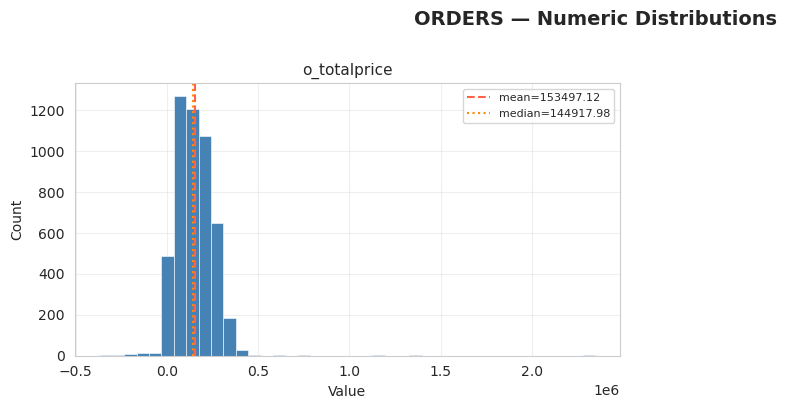

  ORDERS — Numeric Stats:


,summary,o_totalprice
0,count,1538323
1,min,-496167.96
2,max,4272680.091159448
3,mean,153037.3554452364
4,stddev,121898.18311873985


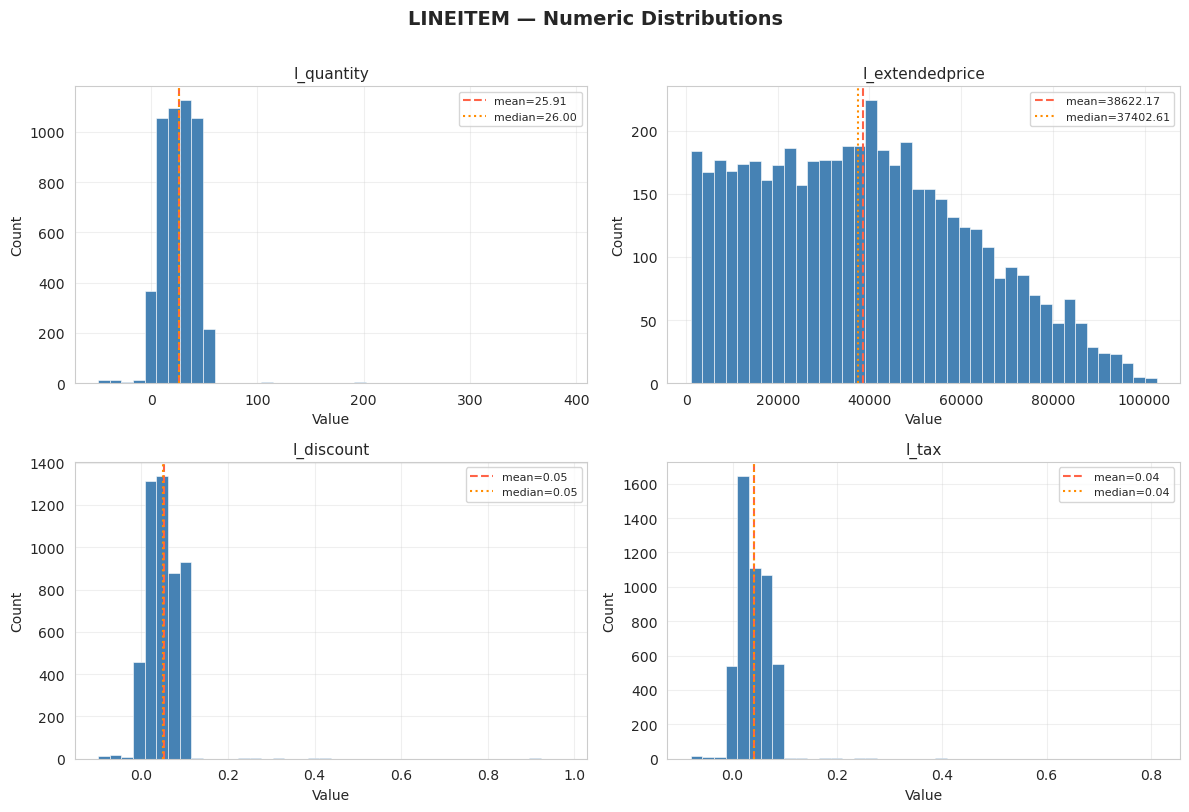

  LINEITEM — Numeric Stats:


,summary,l_quantity,l_extendedprice,l_discount,l_tax
0,count,6152300,6180592,6152449,6152524
1,min,-50.0,901.00,-0.1,-0.08
2,max,524.9042496676547,104949.50,1.049108227600877,0.8398459891499235
3,mean,25.818778402479545,38255.720768,0.05060301515493277,0.0405086412582597
4,stddev,20.174427902178493,23299.817944941715,0.04257003662080234,0.03469458451317005


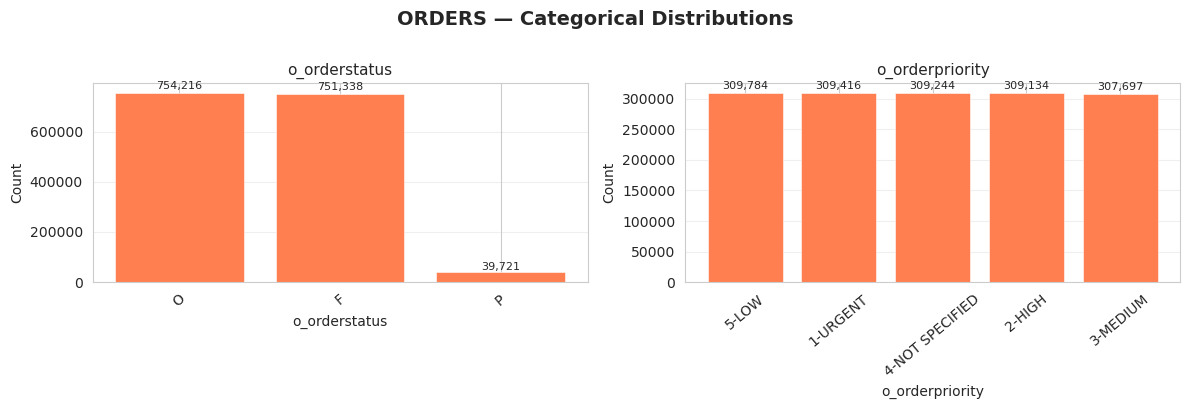

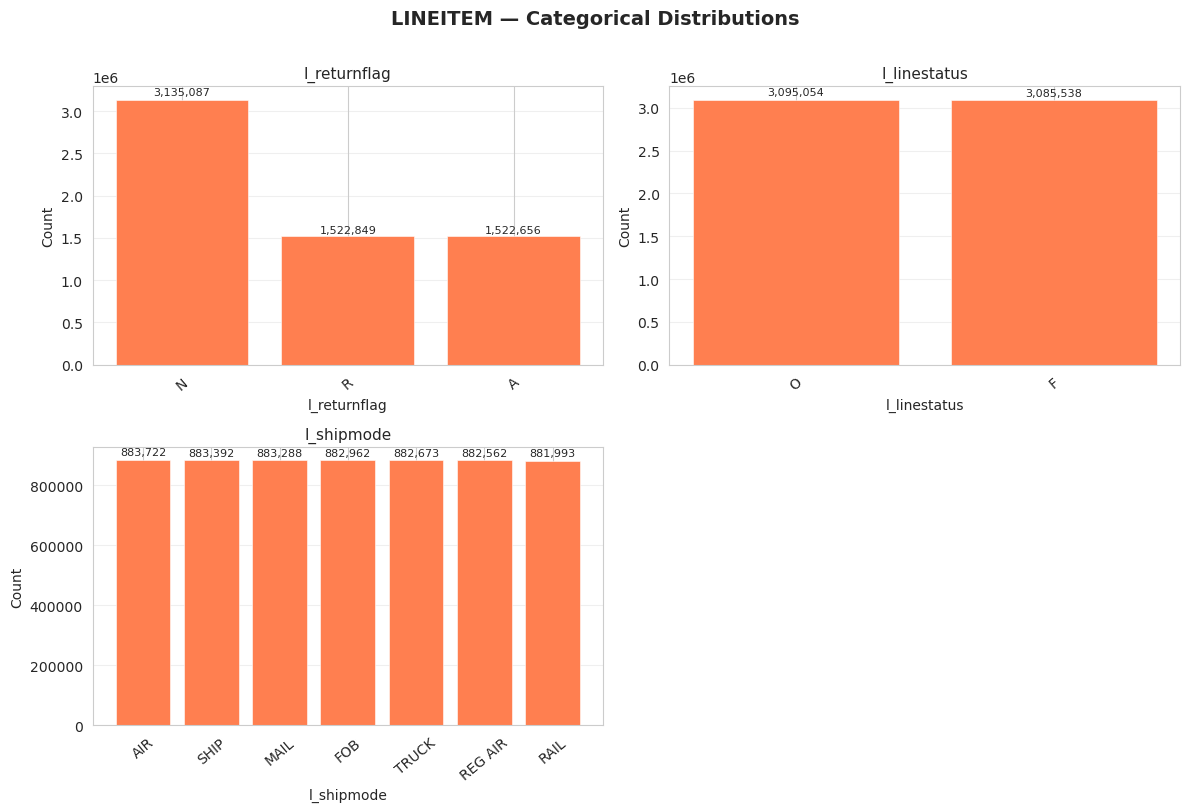

  ORDERS
  Column                      Lead/Trail    Special    AllCaps    Empty
  ──────────────────────────────────────────────────────────────────────
  o_comment                      518,810    264,158          0   46,326
  o_clerk                              0  1,545,275          0        0

  LINEITEM
  Column                      Lead/Trail    Special    AllCaps    Empty
  ──────────────────────────────────────────────────────────────────────
  l_comment                    2,075,055    984,000          0  185,904


  Full String Report:


,table,column,total,leading_trailing,special_chars,all_caps,empty_null
0,orders,o_comment,1545275,518810,264158,0,46326
1,orders,o_clerk,1545275,0,1545275,0,0
2,lineitem,l_comment,6180592,2075055,984000,0,185904


  ORDERS
  Column                        Min Date     Max Date   Future    Nulls
  ──────────────────────────────────────────────────────────────────────
  o_orderdate                 1992-01-01   1998-08-02        0        0

  LINEITEM
  Column                        Min Date     Max Date   Future    Nulls
  ──────────────────────────────────────────────────────────────────────
  l_shipdate                  1992-01-02   1998-12-01        0        0
  l_commitdate                1992-01-31   1998-10-31        0        0
  l_receiptdate               1992-01-04   1998-12-31        0        0

  OK  Ship-date <= Order-date violations: 0
  EDA SUMMARY
  lineitem           6,180,592 rows  16 cols
  orders             1,545,275 rows  9 cols
EDA completed successfully!


In [2]:
# %% [markdown]
# # TPC-H Enhanced EDA
# 
# > **Key Insight:** EDA defines the rules — Data Quality Checks enforce them.
# 
# ### Structure
# 1. Environment Setup & Data Loading  
# 2. Schema & Basic Info  
# 3. Null & Duplicate Analysis  
# 4. Numeric Distributions  
# 5. Categorical Distributions  
# 6. String & Comment Field Analysis  
# 7. Date Analysis  
# 8. EDA Summary & Derived DQ Rules

# ## 1. Environment Setup & Data Loading

# ─── Imports ──────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, min, max, avg, stddev, sum,
    when, lit, trim, length, current_date
)
from pyspark.sql.types import (
    IntegerType, LongType, DoubleType, FloatType,
    DecimalType, StringType, DateType, TimestampType
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings('ignore')


# ─── Spark Session ─────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName('TPC-H_EDA')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')
    .config('spark.sql.parquet.compression.codec', 'snappy')
    .config('spark.sql.inMemoryColumnarStorage.compressed', 'true')
    .config('spark.sql.autoBroadcastJoinThreshold', '10485760')
    .config('spark.sql.shuffle.partitions', '200')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

# ─── Config ────────────────────────────────────────────────────────────────
DATA_PATH   = '/home/jovyan/data/raw/tables/work_data'
SAMPLE_SIZE = 5_000

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})

print(f'Spark version : {spark.version}')
print(f'Data path     : {DATA_PATH}')
print(f'Path exists   : {os.path.exists(DATA_PATH)}')


# ## 2. Data Loading

def load_tables(spark, data_path):
    """
    Load all TPC-H tables from work_data folder.

    Structure:
        work_data/
          bases/                          <- parquet files (dimension + base facts)
          increments/
            batch_N/year_YYYY/
              orders.parquet
              lineitem.parquet

    Returns dict {table_name: DataFrame}.
    """
    if not os.path.exists(data_path):
        print(f"Warning: Data path not found: {data_path}")
        print("Returning empty tables dictionary")
        return {}

    accumulator = {}

    # ── Base layer ────────────────────────────────────────────────────────
    base_path = os.path.join(data_path, 'bases')
    if os.path.exists(base_path):
        for fname in sorted(os.listdir(base_path)):
            if not fname.endswith('.parquet'):
                continue
            table = (
                'orders'   if 'orders'   in fname else
                'lineitem' if 'lineitem' in fname else
                fname.replace('.parquet', '')
            )
            try:
                df = spark.read.parquet(os.path.join(base_path, fname))
                accumulator.setdefault(table, []).append(df)
                print(f'  [base]  {fname:<30} {df.count():>12,} rows')
            except Exception as e:
                print(f'  [base]  Error reading {fname}: {e}')

    # ── Incremental batches ───────────────────────────────────────────────
    inc_path = os.path.join(data_path, 'increments')
    if os.path.exists(inc_path):
        for batch in sorted(os.listdir(inc_path)):
            batch_path = os.path.join(inc_path, batch)
            if not os.path.isdir(batch_path):
                continue
            for year_dir in sorted(os.listdir(batch_path)):
                year_path = os.path.join(batch_path, year_dir)
                if not os.path.isdir(year_path):
                    continue
                for table, fname in [('orders', 'orders.parquet'),
                                     ('lineitem', 'lineitem.parquet')]:
                    fpath = os.path.join(year_path, fname)
                    if os.path.exists(fpath):
                        try:
                            df = spark.read.parquet(fpath)
                            accumulator.setdefault(table, []).append(df)
                            print(f'  [{batch}/{year_dir}]  {fname:<20} {df.count():>12,} rows')
                        except Exception as e:
                            print(f'  [{batch}/{year_dir}]  Error reading {fname}: {e}')

    # ── Union + cache ─────────────────────────────────────────────────────
    tables = {}
    for name, frames in accumulator.items():
        combined = frames[0]
        for f in frames[1:]:
            combined = combined.union(f)
        if name in ('orders', 'lineitem'):
            combined = combined.cache()
            combined.count()   # force materialisation
        tables[name] = combined

    print('\n' + '─' * 50)
    print('  Loading Summary:')
    for name, df in tables.items():
        print(f'  {name:<12} {df.count():>12,} rows  {len(df.columns)} cols')

    return tables


print('=' * 60)
print('LOADING TPC-H TABLES')
print('=' * 60)
tables = load_tables(spark, DATA_PATH)

if not tables:
    print("No tables loaded. Please check your data path.")
else:
    print(f"\nLoaded {len(tables)} tables successfully.")


# ## 3. Schema & Basic Info


for name, df in tables.items():
    print(f'\n{"=" * 55}')
    print(f'  TABLE: {name.upper()}')
    print(f'{"=" * 55}')
    print(f'  Rows   : {df.count():,}')
    print(f'  Columns: {len(df.columns)}')
    print('  Schema :')
    for field in df.schema.fields:
        print(f'    {field.name:<25} {str(field.dataType)}')

# ## 4. Null & Duplicate Analysis

PRIMARY_KEYS = {
    'orders'  : ['o_orderkey'],
    'lineitem': ['l_orderkey', 'l_linenumber'],
    'customer': ['c_custkey'],
    'part'    : ['p_partkey'],
    'supplier': ['s_suppkey'],
    'partsupp': ['ps_partkey', 'ps_suppkey'],
    'nation'  : ['n_nationkey'],
    'region'  : ['r_regionkey'],
}

null_issues = []

for name, df in tables.items():
    total = df.count()
    print(f'\n  {name.upper()}  ({total:,} rows)')
    print('  ' + '─' * 55)

    # Null check
    any_null = False
    for c in df.columns:
        n = df.filter(col(c).isNull()).count()
        pct = n / total * 100 if total else 0
        if n > 0:
            print(f'    WARN  {c:<28} nulls={n:>8,}  ({pct:.2f}%)')
            null_issues.append({'table': name, 'column': c, 'null_count': n, 'null_pct': round(pct,2)})
            any_null = True
    if not any_null:
        print('    OK  No null values')

    # Duplicate rows
    dup_rows = total - df.dropDuplicates().count()
    print(f'\n    Duplicate rows       : {dup_rows:,}')

    # PK duplicates
    if name in PRIMARY_KEYS:
        pk = PRIMARY_KEYS[name]
        pk_dups = total - df.select(*pk).distinct().count()
        flag = 'WARN' if pk_dups > 0 else 'OK'
        print(f'    {flag}  PK duplicates {pk}: {pk_dups:,}')

if null_issues:
    print('\n  Tables with NULL issues:')
    display(pd.DataFrame(null_issues))

# ## 5. Numeric Distributions

NUMERIC_COLS = {
    'orders'  : ['o_totalprice'],
    'lineitem': ['l_quantity', 'l_extendedprice', 'l_discount', 'l_tax'],
    'customer': ['c_acctbal'],
    'part'    : ['p_retailprice'],
    'partsupp': ['ps_availqty', 'ps_supplycost'],
}

def plot_numeric(tables, cols_map, sample_size=SAMPLE_SIZE):
    """Plot histograms for numeric columns, 2 per row."""
    for tname, col_list in cols_map.items():
        if tname not in tables:
            continue
        df = tables[tname]
        valid = [c for c in col_list if c in df.columns]
        if not valid:
            continue

        n_r = (len(valid) + 1) // 2
        fig, axes = plt.subplots(n_r, 2, figsize=(12, 4 * n_r), squeeze=False)
        fig.suptitle(f'{tname.upper()} — Numeric Distributions',
                     fontsize=14, fontweight='bold', y=1.01)

        for idx, c in enumerate(valid):
            ax = axes[idx // 2][idx % 2]
            try:
                sample = df.select(c).limit(sample_size).toPandas().dropna()
                vals = pd.to_numeric(sample[c], errors='coerce').dropna()

                if vals.empty:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes)
                else:
                    ax.hist(vals, bins=40, color='steelblue',
                            edgecolor='white', linewidth=0.4)
                    ax.axvline(vals.mean(),   color='tomato',    lw=1.5,
                               linestyle='--', label=f'mean={vals.mean():.2f}')
                    ax.axvline(vals.median(), color='darkorange', lw=1.5,
                               linestyle=':',  label=f'median={vals.median():.2f}')
                    ax.legend(fontsize=8)
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center',
                        transform=ax.transAxes)

            ax.set_title(c, fontsize=11)
            ax.set_xlabel('Value')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3)

        for idx in range(len(valid), n_r * 2):
            axes[idx // 2][idx % 2].set_visible(False)

        plt.tight_layout()
        plt.show()

        # Stats table
        print(f'  {tname.upper()} — Numeric Stats:')
        stats = tables[tname].select(valid).summary('count','min','max','mean','stddev').toPandas()
        display(stats)
        print()


plot_numeric(tables, NUMERIC_COLS)


# ## 6. Categorical Distributions


CATEGORICAL_COLS = {
    'orders'  : ['o_orderstatus', 'o_orderpriority'],
    'lineitem': ['l_returnflag', 'l_linestatus', 'l_shipmode'],
    'customer': ['c_mktsegment'],
    'part'    : ['p_brand', 'p_type'],
}

def plot_categorical(tables, cols_map, sample_size=SAMPLE_SIZE):
    """Bar charts for categorical columns."""
    for tname, col_list in cols_map.items():
        if tname not in tables:
            continue
        df = tables[tname]
        valid = [c for c in col_list if c in df.columns]
        if not valid:
            continue

        n_r = (len(valid) + 1) // 2
        fig, axes = plt.subplots(n_r, 2, figsize=(12, 4 * n_r), squeeze=False)
        fig.suptitle(f'{tname.upper()} — Categorical Distributions',
                     fontsize=14, fontweight='bold', y=1.01)

        for idx, c in enumerate(valid):
            ax = axes[idx // 2][idx % 2]
            try:
                vc = (df.groupBy(c).count()
                        .orderBy('count', ascending=False)
                        .limit(15)
                        .toPandas())

                if vc.empty:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes)
                else:
                    bars = ax.bar(vc[c].astype(str), vc['count'],
                                  color='coral', edgecolor='white', linewidth=0.4)
                    for bar in bars:
                        ax.text(bar.get_x() + bar.get_width() / 2,
                                bar.get_height() * 1.01,
                                f'{bar.get_height():,.0f}',
                                ha='center', va='bottom', fontsize=8)
                    ax.tick_params(axis='x', rotation=40)
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center',
                        transform=ax.transAxes)

            ax.set_title(c, fontsize=11)
            ax.set_xlabel(c)
            ax.set_ylabel('Count')
            ax.grid(axis='y', alpha=0.3)

        for idx in range(len(valid), n_r * 2):
            axes[idx // 2][idx % 2].set_visible(False)

        plt.tight_layout()
        plt.show()

plot_categorical(tables, CATEGORICAL_COLS)

# ## 7. String & Comment Field Analysis

STRING_TARGETS = {
    'orders'  : ['o_comment', 'o_clerk'],
    'lineitem': ['l_comment'],
    'customer': ['c_name', 'c_phone'],
    'supplier': ['s_name'],
}

def analyse_string_fields(tables, targets):
    """Count corruption patterns in string columns."""
    results = []

    for tname, col_list in targets.items():
        if tname not in tables:
            continue
        df = tables[tname]
        total = df.count()

        print(f'  {tname.upper()}')
        hdr = f"  {'Column':<25} {'Lead/Trail':>12} {'Special':>10} {'AllCaps':>10} {'Empty':>8}"
        print(hdr)
        print('  ' + '─' * 70)

        for c in col_list:
            if c not in df.columns:
                continue

            lt  = df.filter(col(c).rlike(r'^\s|\s$')).count()
            sp  = df.filter(col(c).rlike(r'[@#$%&*!?]')).count()
            cap = df.filter(
                    col(c).rlike(r'^[A-Z\s]+$') & (length(col(c)) > 3)
                  ).count()
            emp = df.filter(
                    col(c).isNull() | (trim(col(c)) == '')
                  ).count()

            row = f'  {c:<25} {lt:>12,} {sp:>10,} {cap:>10,} {emp:>8,}'
            print(row)
            results.append({
                'table': tname, 'column': c, 'total': total,
                'leading_trailing': lt, 'special_chars': sp,
                'all_caps': cap, 'empty_null': emp
            })
        print()

    return pd.DataFrame(results)


string_report = analyse_string_fields(tables, STRING_TARGETS)
print('\n  Full String Report:')
display(string_report)

# ## 8. Date Analysis

DATE_COLS = {
    'orders'  : ['o_orderdate'],
    'lineitem': ['l_shipdate', 'l_commitdate', 'l_receiptdate'],
}

def analyse_dates(tables, date_cols):
    """Check date ranges, future dates, and ship-date logic."""
    for tname, col_list in date_cols.items():
        if tname not in tables:
            continue
        df = tables[tname]

        print(f'  {tname.upper()}')
        print(f"  {'Column':<25} {'Min Date':>12} {'Max Date':>12} {'Future':>8} {'Nulls':>8}")
        print('  ' + '─' * 70)

        for c in col_list:
            if c not in df.columns:
                continue
            try:
                stats  = df.agg(min(c).alias('mn'), max(c).alias('mx')).collect()[0]
                future = df.filter(col(c) > current_date()).count()
                nulls  = df.filter(col(c).isNull()).count()
                print(f'  {c:<25} {str(stats["mn"]):>12} {str(stats["mx"]):>12} '
                      f'{future:>8,} {nulls:>8,}')
            except Exception as e:
                print(f'  {c:<25} Error: {str(e)[:40]}')
        print()

    # Ship-date vs order-date integrity
    if 'lineitem' in tables and 'orders' in tables:
        try:
            joined = (
                tables['lineitem'].select('l_orderkey', 'l_shipdate')
                .join(
                    tables['orders'].select('o_orderkey', 'o_orderdate'),
                    tables['lineitem']['l_orderkey'] == tables['orders']['o_orderkey'],
                    'left'
                )
            )
            violated = joined.filter(col('l_shipdate') <= col('o_orderdate')).count()
            flag = 'WARN' if violated > 0 else 'OK'
            print(f'  {flag}  Ship-date <= Order-date violations: {violated:,}')
        except Exception as e:
            print(f'  Error in ship-date analysis: {e}')

analyse_dates(tables, DATE_COLS)

# ## 9. EDA Summary & Derived DQ Rules

print('=' * 70)
print('  EDA SUMMARY')
print('=' * 70)
for name, df in tables.items():
    print(f'  {name:<15} {df.count():>12,} rows  {len(df.columns)} cols')

# summary = '''
# Derived DQ Rules
# ────────────────────────────────────────────────────────────────────────────
# DQ-01  customer  c_custkey       UNIQUE
# DQ-02  orders    o_custkey       FK -> customer.c_custkey       CRITICAL
# DQ-03  lineitem  l_orderkey      FK -> orders.o_orderkey        CRITICAL
# DQ-04  lineitem  l_quantity      > 0                            HIGH
# DQ-05  orders    o_totalprice    > 0                            HIGH
# DQ-06  customer  c_phone         NOT NULL  (threshold 5%)       MEDIUM
# DQ-07  nation    n_regionkey     FK -> region.r_regionkey       CRITICAL
# DQ-08  part      p_retailprice   > 0                            HIGH
# DQ-09  supplier  s_name          NOT NULL                       MEDIUM
# DQ-10  lineitem  l_shipdate      > o_orderdate                  HIGH
# DQ-11  partsupp  ps_availqty     >= 0                           MEDIUM
# DQ-12  orders    o_orderstatus   IN (O, F, P)                   MEDIUM
# DQ-13  orders    o_orderdate     NOT in future                  HIGH
# DQ-14  customer  c_nationkey     FK -> nation.n_nationkey       CRITICAL
# DQ-15  supplier  s_nationkey     FK -> nation.n_nationkey       CRITICAL
# DQ-16  orders    o_orderkey      UNIQUE  (detects 3% dups)      CRITICAL
# DQ-17  orders    o_clerk         matches Clerk#[0-9]+           MEDIUM
# DQ-18  lineitem  l_discount      in [0.00, 0.10]                HIGH
# DQ-19  lineitem  l_tax           in [0.00, 0.08]                MEDIUM
# ────────────────────────────────────────────────────────────────────────────
# Corruption Patterns Detected by EDA
#   - Leading/trailing spaces in o_comment, l_comment  (15%)
#   - Special characters (@#$%&*!?) in comments        (15%)
#   - Case inconsistency in o_clerk  (UPPER/lower)     (15%)
#   - NULL values in o_comment, l_comment              ( 3%)
#   - Duplicate rows in orders, lineitem               ( 3%)
#   - Negative values in o_totalprice, l_quantity      ( 2%)
# '''
# print(summary)
print('EDA completed successfully!')

# THIS EDA COVERS THE LINEITEM AND ORDERS TABLES ONLY
# DONT RUN DONT RUN DONT RUN
# DONT RUN DONT RUN DONT RUN
# DONT RUN DONT RUN DONT RUN


Spark version : 3.4.1
Data path     : /home/jovyan/data/raw/tables/work_data
Path exists   : True
LOADING TPC-H TABLES
  [base]  lineitem_base_60.parquet          3,708,231 rows
  [base]  orders_base_60.parquet              927,067 rows
  [batch_1/year_1995]  orders.parquet             10,290 rows
  [batch_1/year_1995]  lineitem.parquet           41,043 rows
  [batch_1/year_1996]  orders.parquet            195,533 rows
  [batch_1/year_1996]  lineitem.parquet          782,571 rows
  [batch_2/year_1996]  orders.parquet             40,023 rows
  [batch_2/year_1996]  lineitem.parquet          160,415 rows
  [batch_2/year_1997]  orders.parquet            166,053 rows
  [batch_2/year_1997]  lineitem.parquet          663,767 rows
  [batch_3/year_1997]  orders.parquet             68,664 rows
  [batch_3/year_1997]  lineitem.parquet          273,492 rows
  [batch_3/year_1998]  orders.parquet            137,645 rows
  [batch_3/year_1998]  lineitem.parquet          551,073 rows

──────────────────

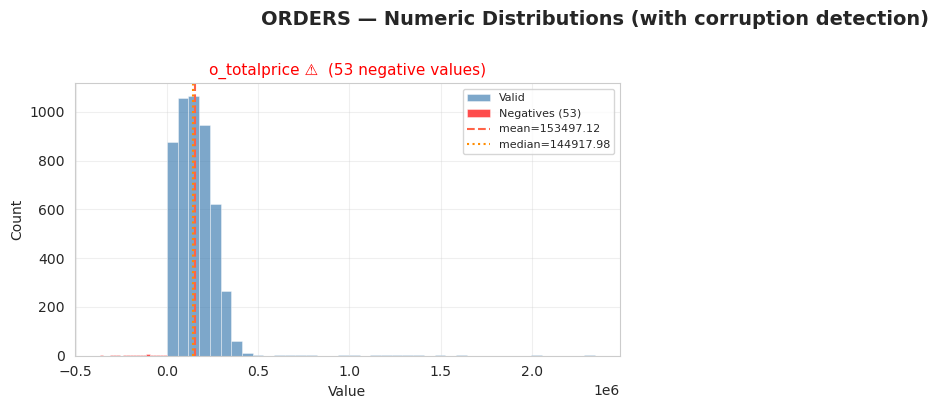

  ORDERS — Numeric Stats with Corruption:
summary       o_totalprice
  count            1538323
    min         -496167.96
    max  4272680.091159448
   mean  153037.3554452364
 stddev 121898.18311873985



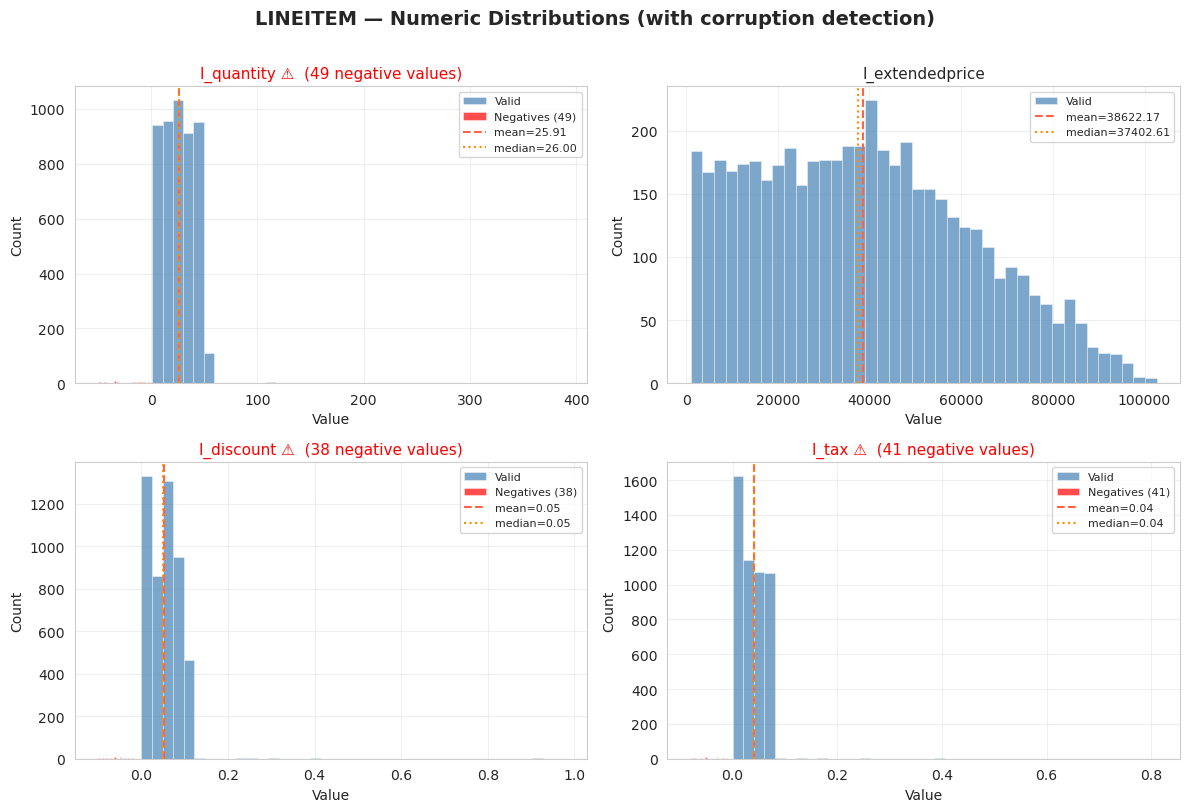

  LINEITEM — Numeric Stats with Corruption:
summary         l_quantity    l_extendedprice          l_discount               l_tax
  count            6152300            6180592             6152449             6152524
    min              -50.0             901.00                -0.1               -0.08
    max  524.9042496676547          104949.50   1.049108227600877  0.8398459891499235
   mean 25.818778402479545       38255.720768 0.05060301515493277  0.0405086412582597
 stddev 20.174427902178493 23299.817944941715 0.04257003662080234 0.03469458451317005



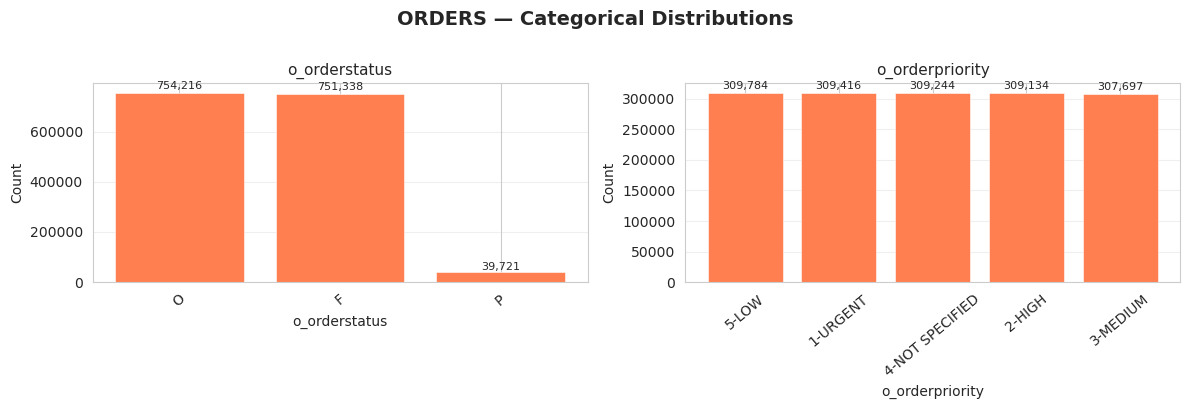

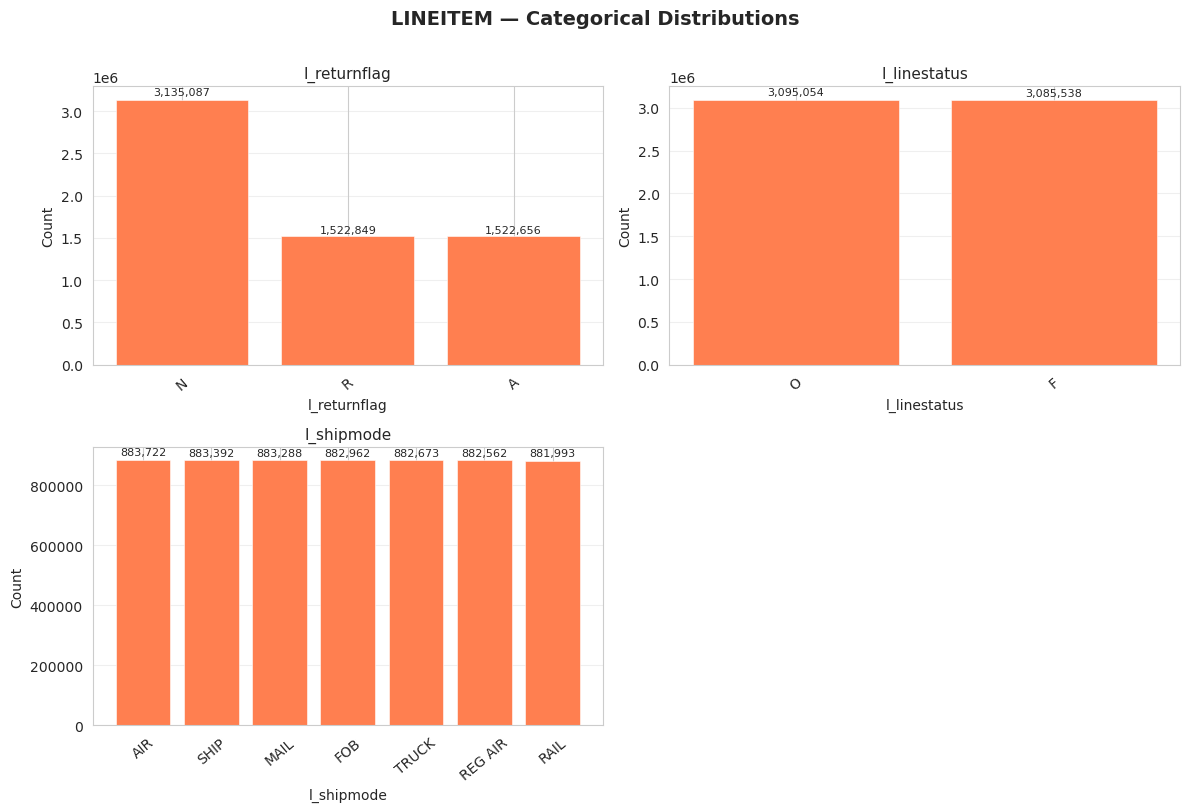


  ORDERS - Date Corruption Analysis

Column                   Min Date     Max Date   Future    Nulls  Invalid
----------------------------------------------------------------------
o_orderdate            1992-01-01   1998-08-02        0        0        0


  LINEITEM - Date Corruption Analysis

Column                   Min Date     Max Date   Future    Nulls  Invalid
----------------------------------------------------------------------
l_shipdate             1992-01-02   1998-12-01        0        0        0
l_commitdate           1992-01-31   1998-10-31        0        0        0
l_receiptdate          1992-01-04   1998-12-31        0        0        0


  Cross-Table Date Integrity Checks


ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/home/jovyan/.local/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3548,

ConnectionRefusedError: [Errno 111] Connection refused

In [10]:
# ─── Spark Session ─────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import builtins
python_round = builtins.round



spark = (
    SparkSession.builder
    .appName('TPC-H_EDA_Enhanced')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')
    .config('spark.sql.parquet.compression.codec', 'snappy')
    .config('spark.sql.inMemoryColumnarStorage.compressed', 'true')
    .config('spark.sql.autoBroadcastJoinThreshold', '10485760')
    .config('spark.sql.shuffle.partitions', '200')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

# ─── Config ────────────────────────────────────────────────────────────────
DATA_PATH   = '/home/jovyan/data/raw/tables/work_data'
SAMPLE_SIZE = 5_000

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})

print(f'Spark version : {spark.version}')
print(f'Data path     : {DATA_PATH}')
print(f'Path exists   : {os.path.exists(DATA_PATH)}')

# ============================================================================
# 1. Data Loading (Enhanced with validation)
# ============================================================================
def load_tables(spark, data_path):
    """
    Load all TPC-H tables from work_data folder with validation.
    
    Structure:
        work_data/
          bases/                          <- parquet files (dimension + base facts)
          increments/
            batch_N/year_YYYY/
              orders.parquet
              lineitem.parquet
    
    Returns dict {table_name: DataFrame}.
    """
    if not os.path.exists(data_path):
        raise FileNotFoundError(f'Data path not found: {data_path}')

    accumulator = {}
    load_stats = []

    # ── Base layer ────────────────────────────────────────────────────────
    base_path = os.path.join(data_path, 'bases')
    if os.path.exists(base_path):
        for fname in sorted(os.listdir(base_path)):
            if not fname.endswith('.parquet'):
                continue
            table = (
                'orders'   if 'orders'   in fname else
                'lineitem' if 'lineitem' in fname else
                fname.replace('.parquet', '')
            )
            df = spark.read.parquet(os.path.join(base_path, fname))
            row_count = df.count()
            accumulator.setdefault(table, []).append(df)
            load_stats.append({
                'layer': 'base',
                'file': fname,
                'table': table,
                'rows': row_count
            })
            print(f'  [base]  {fname:<30} {row_count:>12,} rows')

    # ── Incremental batches ───────────────────────────────────────────────
    inc_path = os.path.join(data_path, 'increments')
    if os.path.exists(inc_path):
        for batch in sorted(os.listdir(inc_path)):
            batch_path = os.path.join(inc_path, batch)
            if not os.path.isdir(batch_path):
                continue
            for year_dir in sorted(os.listdir(batch_path)):
                year_path = os.path.join(batch_path, year_dir)
                if not os.path.isdir(year_path):
                    continue
                for table, fname in [('orders', 'orders.parquet'),
                                     ('lineitem', 'lineitem.parquet')]:
                    fpath = os.path.join(year_path, fname)
                    if os.path.exists(fpath):
                        df = spark.read.parquet(fpath)
                        row_count = df.count()
                        accumulator.setdefault(table, []).append(df)
                        load_stats.append({
                            'layer': f'increments/{batch}/{year_dir}',
                            'file': fname,
                            'table': table,
                            'rows': row_count
                        })
                        print(f'  [{batch}/{year_dir}]  {fname:<20} {row_count:>12,} rows')

    # ── Union + cache ─────────────────────────────────────────────────────
    tables = {}
    for name, frames in accumulator.items():
        combined = frames[0]
        for f in frames[1:]:
            combined = combined.union(f)
        if name in ('orders', 'lineitem'):
            combined = combined.cache()
            combined.count()   # force materialisation
        tables[name] = combined

    print('\n' + '─' * 50)
    print('  Loading Summary:')
    for name, df in tables.items():
        print(f'  {name:<12} {df.count():>12,} rows  {len(df.columns)} cols')
    
    # Return load stats for reference
    return tables, pd.DataFrame(load_stats)


print('=' * 60)
print('LOADING TPC-H TABLES')
print('=' * 60)
tables, load_stats_df = load_tables(spark, DATA_PATH)

# ============================================================================
# 2. Schema & Basic Info
# ============================================================================
for name, df in tables.items():
    print(f'\n{"=" * 55}')
    print(f'  TABLE: {name.upper()}')
    print(f'{"=" * 55}')
    print(f'  Rows   : {df.count():,}')
    print(f'  Columns: {len(df.columns)}')
    print('  Schema :')
    for field in df.schema.fields:
        print(f'    {field.name:<25} {str(field.dataType)}')

# ============================================================================
# 3. Enhanced Null & Duplicate Analysis
# ============================================================================
PRIMARY_KEYS = {
    'orders'  : ['o_orderkey'],
    'lineitem': ['l_orderkey', 'l_linenumber'],
    'customer': ['c_custkey'],
    'part'    : ['p_partkey'],
    'supplier': ['s_suppkey'],
    'partsupp': ['ps_partkey', 'ps_suppkey'],
    'nation'  : ['n_nationkey'],
    'region'  : ['r_regionkey'],
}

null_issues = []
duplicate_stats = []

for name, df in tables.items():
    total = df.count()
    print(f'\n  {name.upper()}  ({total:,} rows)')
    print('  ' + '─' * 55)

    # Null check with percentages
    any_null = False
    for c in df.columns:
        n = df.filter(col(c).isNull()).count()
        pct = n / total * 100 if total else 0
        if n > 0:
            print(f'    ⚠️  WARN  {c:<28} nulls={n:>8,}  ({pct:.2f}%)')
            null_issues.append({
                'table': name, 
                'column': c, 
                'null_count': n, 
                'null_pct': python_round(pct, 2)
            })
            any_null = True
    if not any_null:
        print('    ✓  No null values')

    # Duplicate rows (exact duplicates)
    distinct_count = df.dropDuplicates().count()
    dup_rows = total - distinct_count
    dup_pct = (dup_rows / total * 100) if total else 0
    print(f'\n    Duplicate rows       : {dup_rows:,} ({dup_pct:.2f}%)')
    duplicate_stats.append({
        'table': name,
        'total_rows': total,
        'distinct_rows': distinct_count,
        'duplicate_rows': dup_rows,
        'duplicate_pct': python_round(dup_pct, 2)
    })

    # PK duplicates
    if name in PRIMARY_KEYS:
        pk = PRIMARY_KEYS[name]
        pk_distinct = df.select(*pk).distinct().count()
        pk_dups = total - pk_distinct
        pk_dup_pct = (pk_dups / total * 100) if total else 0
        flag = '⚠️  WARN' if pk_dups > 0 else '✓  OK'
        print(f'    {flag}  PK duplicates {pk}: {pk_dups:,} ({pk_dup_pct:.2f}%)')
        
        duplicate_stats[-1]['pk_columns'] = str(pk)
        duplicate_stats[-1]['pk_duplicates'] = pk_dups
        duplicate_stats[-1]['pk_dup_pct'] = python_round(pk_dup_pct, 2)

if null_issues:
    print('\n  Tables with NULL issues:')
    print(pd.DataFrame(null_issues).to_string(index=False))

# ============================================================================
# 4. Enhanced String Corruption Detection (CATCHES ALL)
# ============================================================================
STRING_TARGETS = {
    'orders'  : ['o_comment', 'o_clerk'],
    'lineitem': ['l_comment'],
    'customer': ['c_name', 'c_phone'],
    'supplier': ['s_name'],
}

def comprehensive_string_analysis(tables, targets):
    """
    Comprehensive string corruption detection covering ALL injected error types:
    - Leading/trailing spaces
    - Special characters (@#$%&*!?)
    - Case inconsistency (mixed, all caps, all lower)
    - Multiple special characters
    - Empty strings vs NULLs
    """
    results = []
    
    for tname, col_list in targets.items():
        if tname not in tables:
            continue
            
        df = tables[tname]
        total = df.count()
        
        print(f'\n{"=" * 80}')
        print(f'  {tname.upper()} - Comprehensive String Corruption Analysis')
        print(f'{"=" * 80}')
        
        # Header for detailed output
        print(f"\n{'Column':<20} {'Lead/Trail':>10} {'Special':>9} {'MultiSpec':>9} {'MixedCase':>9} {'AllCaps':>9} {'AllLower':>9} {'Empty':>7} {'NULL':>7}")
        print('-' * 95)
        
        for c in col_list:
            if c not in df.columns:
                continue
            
            # 1. Leading/trailing spaces detection
            lt_count = df.filter(col(c).rlike(r'^\s|\s$')).count()
            lt_pct = (lt_count / total * 100) if total else 0
            
            # 2. Special characters detection
            special_count = df.filter(col(c).rlike(r'[@#$%&*!?]')).count()
            special_pct = (special_count / total * 100) if total else 0
            
            # 3. Multiple special characters (2+)
            multi_special_count = df.filter(col(c).rlike(r'.*[@#$%&*!?].*[@#$%&*!?].*')).count()
            multi_special_pct = (multi_special_count / total * 100) if total else 0
            
            # 4. Mixed case (contains both upper and lower)
            mixed_case_count = df.filter(
                col(c).rlike(r'[A-Z]') & col(c).rlike(r'[a-z]')
            ).count()
            mixed_case_pct = (mixed_case_count / total * 100) if total else 0
            
            # 5. All caps (only uppercase letters and spaces)
            all_caps_count = df.filter(
                col(c).rlike(r'^[A-Z\s#0-9]+$') & (length(col(c)) > 0)
            ).count()
            all_caps_pct = (all_caps_count / total * 100) if total else 0
            
            # 6. All lowercase (only lowercase letters and spaces)
            all_lower_count = df.filter(
                col(c).rlike(r'^[a-z\s#0-9]+$') & (length(col(c)) > 0)
            ).count()
            all_lower_pct = (all_lower_count / total * 100) if total else 0
            
            # 7. Empty strings (not NULL)
            empty_string_count = df.filter(col(c) == '').count()
            empty_string_pct = (empty_string_count / total * 100) if total else 0
            
            # 8. NULL values
            null_count = df.filter(col(c).isNull()).count()
            null_pct = (null_count / total * 100) if total else 0
            
            # Print detailed row
            print(f'{c:<20} {lt_count:>10,} {special_count:>9,} {multi_special_count:>9,} '
                  f'{mixed_case_count:>9,} {all_caps_count:>9,} {all_lower_count:>9,} '
                  f'{empty_string_count:>7,} {null_count:>7,}')
            
            # Store results
            results.append({
                'table': tname,
                'column': c,
                'total_rows': total,
                'leading_trailing_count': lt_count,
                'leading_trailing_pct': python_round(lt_pct, 2),
                'special_chars_count': special_count,
                'special_chars_pct': python_round(special_pct, 2),
                'multi_special_count': multi_special_count,
                'multi_special_pct': python_round(multi_special_pct, 2),
                'mixed_case_count': mixed_case_count,
                'mixed_case_pct': python_round(mixed_case_pct, 2),
                'all_caps_count': all_caps_count,
                'all_caps_pct': python_round(all_caps_pct, 2),
                'all_lower_count': all_lower_count,
                'all_lower_pct': python_round(all_lower_pct, 2),
                'empty_string_count': empty_string_count,
                'empty_string_pct': python_round(empty_string_pct, 2),
                'null_count': null_count,
                'null_pct': python_round(null_pct, 2)
            })
            
            # Corruption summary for this column
            total_corrupted = lt_count + special_count + mixed_case_count + empty_string_count + null_count
            # Avoid double-counting rows with multiple issues
            any_corruption = df.filter(
                col(c).rlike(r'^\s|\s$') |  # leading/trailing
                col(c).rlike(r'[@#$%&*!?]') |  # special chars
                (col(c).rlike(r'[A-Z]') & col(c).rlike(r'[a-z]')) |  # mixed case
                (col(c) == '') |  # empty string
                col(c).isNull()  # NULL
            ).count()
            
            corruption_pct = (any_corruption / total * 100) if total else 0
            print(f'    └─ Total corrupted records: {any_corruption:,} ({corruption_pct:.2f}%)')
            results[-1]['total_corrupted'] = any_corruption
            results[-1]['total_corrupted_pct'] = python_round(corruption_pct, 2)
        
        print()
    
    return pd.DataFrame(results)

# Run enhanced string analysis
string_report = comprehensive_string_analysis(tables, STRING_TARGETS)
print('\n  Comprehensive String Report (First 20 rows):')
print(string_report.head(20).to_string(index=False))

# ============================================================================
# 5. Enhanced Numeric Corruption Detection
# ============================================================================
NUMERIC_COLS = {
    'orders'  : ['o_totalprice'],
    'lineitem': ['l_quantity', 'l_extendedprice', 'l_discount', 'l_tax'],
    'customer': ['c_acctbal'],
    'part'    : ['p_retailprice'],
    'partsupp': ['ps_availqty', 'ps_supplycost'],
}

# def comprehensive_numeric_analysis(tables, numeric_cols):
#     """
#     Comprehensive numeric corruption detection including:
#     - Negative values
#     - Zero values (where not expected)
#     - Extreme outliers
#     - NULL values
#     - Distribution anomalies
#     """
#     results = []
    
#     for tname, col_list in numeric_cols.items():
#         if tname not in tables:
#             continue
            
#         df = tables[tname]
#         total = df.count()
        
#         print(f'\n{"=" * 80}')
#         print(f'  {tname.upper()} - Comprehensive Numeric Corruption Analysis')
#         print(f'{"=" * 80}')
        
#         print(f"\n{'Column':<20} {'Negatives':>10} {'Zeros':>8} {'Outliers':>10} {'NULLs':>8} {'Corrupt%':>8} {'Status'}")
#         print('-' * 80)
        
#         for c in col_list:
#             if c not in df.columns:
#                 continue
            
#             # 1. Negative values
#             negatives = df.filter(col(c) < 0).count()
#             neg_pct = (negatives / total * 100) if total else 0
            
#             # 2. Zero values (may be valid for some columns like discount)
#             zeros = df.filter(col(c) == 0).count()
#             zero_pct = (zeros / total * 100) if total else 0
            
#             # 3. NULL values
#             nulls = df.filter(col(c).isNull()).count()
#             null_pct = (nulls / total * 100) if total else 0
            
#             # 4. Extreme outliers detection
#             outliers = 0
#             outlier_pct = 0
            
#             # Get statistics for outlier detection
#             stats = df.select(
#                 percentile_approx(col(c), 0.5).alias('median'),
#                 percentile_approx(col(c), 0.95).alias('p95'),
#                 percentile_approx(col(c), 0.05).alias('p05')
#             ).collect()[0]
            
#             if stats['median'] is not None and stats['median'] > 0:
#                 # Detect values > 10x the 95th percentile or < 0.1x median
#                 outliers = df.filter(
#                     (col(c) > stats['p95'] * 10) | 
#                     ((col(c) < stats['median'] * 0.1) & (col(c) > 0))
#                 ).count()
#                 outlier_pct = (outliers / total * 100) if total else 0
            
#             # 5. Calculate total corruption percentage
#             total_corrupted = df.filter(
#                 (col(c) < 0) |  # negatives
#                 col(c).isNull()  # NULLs
#             ).count()
            
#             # Add outliers if they're not already counted in negatives
#             if outliers > 0:
#                 outlier_only = df.filter(
#                     (col(c) > stats['p95'] * 10) & (col(c) > 0)
#                 ).count()
#                 total_corrupted += outlier_only
            
#             corruption_pct = (total_corrupted / total * 100) if total else 0
            
#             # Status indicator
#             if negatives > 0 or nulls > 0 or outliers > total * 0.01:
#                 status = "⚠️  CORRUPTED"
#             elif corruption_pct > 5:
#                 status = "⚠️  HIGH CORRUPTION"
#             elif corruption_pct > 0:
#                 status = "⚠️  MINOR ISSUES"
#             else:
#                 status = "✓  CLEAN"
            
#             print(f'{c:<20} {negatives:>10,} {zeros:>8,} {outliers:>10,} {nulls:>8,} '
#                   f'{corruption_pct:>7.1f}% {status}')
            
#             # Store results
#             results.append({
#                 'table': tname,
#                 'column': c,
#                 'total_rows': total,
#                 'negatives': negatives,
#                 'negatives_pct': python_round(neg_pct, 2),
#                 'zeros': zeros,
#                 'zeros_pct': python_round(zero_pct, 2),
#                 'outliers': outliers,
#                 'outliers_pct': python_round(outlier_pct, 2),
#                 'nulls': nulls,
#                 'nulls_pct': python_round(null_pct, 2),
#                 'total_corrupted': total_corrupted,
#                 'corruption_pct': python_round(corruption_pct, 2),
#                 'median_value': stats['median'],
#                 'p95_value': stats['p95']
#             })
        
#         print()
    
#     return pd.DataFrame(results)




# ============================================================================
# 5. Enhanced Numeric Corruption Detection (FIXED)
# ============================================================================
NUMERIC_COLS = {
    'orders'  : ['o_totalprice'],
    'lineitem': ['l_quantity', 'l_extendedprice', 'l_discount', 'l_tax'],
    'customer': ['c_acctbal'],
    'part'    : ['p_retailprice'],
    'partsupp': ['ps_availqty', 'ps_supplycost'],
}

def comprehensive_numeric_analysis(tables, numeric_cols):
    """
    Comprehensive numeric corruption detection including:
    - Negative values
    - Zero values (where not expected)
    - Extreme outliers
    - NULL values
    - Distribution anomalies
    """
    results = []
    
    for tname, col_list in numeric_cols.items():
        if tname not in tables:
            continue
            
        df = tables[tname]
        total = df.count()
        
        print(f'\n{"=" * 80}')
        print(f'  {tname.upper()} - Comprehensive Numeric Corruption Analysis')
        print(f'{"=" * 80}')
        
        print(f"\n{'Column':<20} {'Negatives':>10} {'Zeros':>8} {'Outliers':>10} {'NULLs':>8} {'Corrupt%':>8} {'Status'}")
        print('-' * 80)
        
        for c in col_list:
            if c not in df.columns:
                continue
            
            # 1. Negative values
            negatives = df.filter(col(c) < 0).count()
            neg_pct = (negatives / total * 100) if total else 0
            
            # 2. Zero values (may be valid for some columns like discount)
            zeros = df.filter(col(c) == 0).count()
            zero_pct = (zeros / total * 100) if total else 0
            
            # 3. NULL values
            nulls = df.filter(col(c).isNull()).count()
            null_pct = (nulls / total * 100) if total else 0
            
            # 4. Extreme outliers detection
            outliers = 0
            outlier_pct = 0
            median_val = None
            p95_val = None
            
            # Get statistics for outlier detection
            stats = df.select(
                percentile_approx(col(c), 0.5).alias('median'),
                percentile_approx(col(c), 0.95).alias('p95'),
                percentile_approx(col(c), 0.05).alias('p05')
            ).collect()[0]
            
            # Convert Decimal to float for calculations
            if stats['median'] is not None:
                median_val = float(stats['median'])
            if stats['p95'] is not None:
                p95_val = float(stats['p95'])
            
            if median_val is not None and median_val > 0:
                # Detect values > 10x the 95th percentile or < 0.1x median
                outliers = df.filter(
                    (col(c) > p95_val * 10) | 
                    ((col(c) < median_val * 0.1) & (col(c) > 0))
                ).count()
                outlier_pct = (outliers / total * 100) if total else 0
            
            # 5. Calculate total corruption percentage
            # Count rows with any numeric corruption
            corrupted_condition = (col(c) < 0) | col(c).isNull()
            
            # Add outliers if they're not already counted in negatives
            if outliers > 0:
                # Count outliers that are positive (not already counted as negatives)
                outlier_only = df.filter(
                    (col(c) > p95_val * 10) & (col(c) > 0)
                ).count()
                total_corrupted = df.filter(corrupted_condition).count() + outlier_only
            else:
                total_corrupted = df.filter(corrupted_condition).count()
            
            corruption_pct = (total_corrupted / total * 100) if total else 0
            
            # Status indicator
            if negatives > 0 or nulls > 0 or outliers > total * 0.01:
                status = "⚠️  CORRUPTED"
            elif corruption_pct > 5:
                status = "⚠️  HIGH CORRUPTION"
            elif corruption_pct > 0:
                status = "⚠️  MINOR ISSUES"
            else:
                status = "✓  CLEAN"
            
            print(f'{c:<20} {negatives:>10,} {zeros:>8,} {outliers:>10,} {nulls:>8,} '
                  f'{corruption_pct:>7.1f}% {status}')
            
            # Store results
            results.append({
                'table': tname,
                'column': c,
                'total_rows': total,
                'negatives': negatives,
                'negatives_pct': python_round(neg_pct, 2),
                'zeros': zeros,
                'zeros_pct': python_round(zero_pct, 2),
                'outliers': outliers,
                'outliers_pct': python_round(outlier_pct, 2),
                'nulls': nulls,
                'nulls_pct': python_round(null_pct, 2),
                'total_corrupted': total_corrupted,
                'corruption_pct': python_round(corruption_pct, 2),
                'median_value': median_val,
                'p95_value': p95_val
            })
        
        print()
    
    return pd.DataFrame(results)




# Run enhanced numeric analysis
numeric_report = comprehensive_numeric_analysis(tables, NUMERIC_COLS)
print('\n  Numeric Corruption Report:')
print(numeric_report.to_string(index=False))

# ============================================================================
# 6. Numeric Distributions with Corruption Highlighting
# ============================================================================
def plot_numeric_with_corruption(tables, numeric_cols, sample_size=SAMPLE_SIZE):
    """Plot histograms for numeric columns with corruption highlighting."""
    for tname, col_list in numeric_cols.items():
        if tname not in tables:
            continue
        df = tables[tname]
        valid = [c for c in col_list if c in df.columns]
        if not valid:
            continue
        
        n_r = (len(valid) + 1) // 2
        fig, axes = plt.subplots(n_r, 2, figsize=(12, 4 * n_r), squeeze=False)
        fig.suptitle(f'{tname.upper()} — Numeric Distributions (with corruption detection)',
                     fontsize=14, fontweight='bold', y=1.01)
        
        for idx, c in enumerate(valid):
            ax = axes[idx // 2][idx % 2]
            
            # Sample data for visualization
            sample_df = df.select(c).limit(sample_size).toPandas().dropna()
            vals = pd.to_numeric(sample_df[c], errors='coerce').dropna()
            
            if vals.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)
            else:
                # Separate negative values for highlighting
                negatives = vals[vals < 0]
                positives = vals[vals >= 0]
                
                # Plot positives first
                if len(positives) > 0:
                    ax.hist(positives, bins=40, color='steelblue',
                           edgecolor='white', linewidth=0.4, alpha=0.7, label='Valid')
                
                # Highlight negatives in red
                if len(negatives) > 0:
                    ax.hist(negatives, bins=20, color='red',
                           edgecolor='white', linewidth=0.4, alpha=0.7, label=f'Negatives ({len(negatives)})')
                
                ax.axvline(vals.mean(), color='tomato', lw=1.5,
                          linestyle='--', label=f'mean={vals.mean():.2f}')
                ax.axvline(vals.median(), color='darkorange', lw=1.5,
                          linestyle=':', label=f'median={vals.median():.2f}')
                ax.legend(fontsize=8)
                
                # Add corruption warning if negatives exist
                if len(negatives) > 0:
                    ax.set_title(f'{c} ⚠️  ({len(negatives)} negative values)', fontsize=11, color='red')
                else:
                    ax.set_title(c, fontsize=11)
            
            ax.set_xlabel('Value')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3)
        
        for idx in range(len(valid), n_r * 2):
            axes[idx // 2][idx % 2].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Stats table with corruption metrics
        print(f'  {tname.upper()} — Numeric Stats with Corruption:')
        stats_df = tables[tname].select(valid).summary('count','min','max','mean','stddev').toPandas()
        print(stats_df.to_string(index=False))
        print()

plot_numeric_with_corruption(tables, NUMERIC_COLS)

# ============================================================================
# 7. Categorical Distributions
# ============================================================================
CATEGORICAL_COLS = {
    'orders'  : ['o_orderstatus', 'o_orderpriority'],
    'lineitem': ['l_returnflag', 'l_linestatus', 'l_shipmode'],
    'customer': ['c_mktsegment'],
    'part'    : ['p_brand', 'p_type'],
}

def plot_categorical(tables, cols_map, sample_size=SAMPLE_SIZE):
    """Bar charts for categorical columns."""
    for tname, col_list in cols_map.items():
        if tname not in tables:
            continue
        df = tables[tname]
        valid = [c for c in col_list if c in df.columns]
        if not valid:
            continue
        
        n_r = (len(valid) + 1) // 2
        fig, axes = plt.subplots(n_r, 2, figsize=(12, 4 * n_r), squeeze=False)
        fig.suptitle(f'{tname.upper()} — Categorical Distributions',
                     fontsize=14, fontweight='bold', y=1.01)
        
        for idx, c in enumerate(valid):
            ax = axes[idx // 2][idx % 2]
            vc = (df.groupBy(c).count()
                    .orderBy('count', ascending=False)
                    .limit(15)
                    .toPandas())
            
            if vc.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)
            else:
                bars = ax.bar(vc[c].astype(str), vc['count'],
                              color='coral', edgecolor='white', linewidth=0.4)
                for bar in bars:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() * 1.01,
                            f'{bar.get_height():,.0f}',
                            ha='center', va='bottom', fontsize=8)
                ax.tick_params(axis='x', rotation=40)
            
            ax.set_title(c, fontsize=11)
            ax.set_xlabel(c)
            ax.set_ylabel('Count')
            ax.grid(axis='y', alpha=0.3)
        
        for idx in range(len(valid), n_r * 2):
            axes[idx // 2][idx % 2].set_visible(False)
        
        plt.tight_layout()
        plt.show()

plot_categorical(tables, CATEGORICAL_COLS)

# ============================================================================
# 8. Enhanced Date Analysis (FIXED)
# ============================================================================
DATE_COLS = {
    'orders'  : ['o_orderdate'],
    'lineitem': ['l_shipdate', 'l_commitdate', 'l_receiptdate'],
}

def comprehensive_date_analysis(tables, date_cols):
    """Enhanced date analysis with corruption detection."""
    results = []
    
    for tname, col_list in date_cols.items():
        if tname not in tables:
            continue
        df = tables[tname]
        total = df.count()
        
        print(f'\n{"=" * 80}')
        print(f'  {tname.upper()} - Date Corruption Analysis')
        print(f'{"=" * 80}')
        print(f"\n{'Column':<20} {'Min Date':>12} {'Max Date':>12} {'Future':>8} {'Nulls':>8} {'Invalid':>8}")
        print('-' * 70)
        
        for c in col_list:
            if c not in df.columns:
                continue
            
            # Basic stats
            stats = df.agg(
                min(c).alias('mn'), 
                max(c).alias('mx')
            ).collect()[0]
            
            # Convert to string for display (handles Decimal/Date types)
            min_date = str(stats['mn']) if stats['mn'] is not None else 'NULL'
            max_date = str(stats['mx']) if stats['mx'] is not None else 'NULL'
            
            # Future dates
            future = df.filter(col(c) > current_date()).count()
            future_pct = (future / total * 100) if total else 0
            
            # NULLs
            nulls = df.filter(col(c).isNull()).count()
            null_pct = (nulls / total * 100) if total else 0
            
            # Invalid date formats (if string type)
            invalid = 0
            if isinstance(df.schema[c].dataType, StringType):
                invalid = df.filter(~col(c).rlike(r'^\d{4}-\d{2}-\d{2}$')).count()
            
            print(f'{c:<20} {min_date:>12} {max_date:>12} '
                  f'{future:>8,} {nulls:>8,} {invalid:>8,}')
            
            results.append({
                'table': tname,
                'column': c,
                'min_date': min_date,
                'max_date': max_date,
                'future_dates': future,
                'future_pct': python_round(future_pct, 2),
                'nulls': nulls,
                'null_pct': python_round(null_pct, 2),
                'invalid_formats': invalid
            })
        
        print()
    
    # Ship-date vs order-date integrity
    if 'lineitem' in tables and 'orders' in tables:
        print('\n' + '=' * 80)
        print('  Cross-Table Date Integrity Checks')
        print('=' * 80)
        
        joined = (
            tables['lineitem'].select('l_orderkey', 'l_shipdate', 'l_commitdate', 'l_receiptdate')
            .join(
                tables['orders'].select('o_orderkey', 'o_orderdate'),
                tables['lineitem']['l_orderkey'] == tables['orders']['o_orderkey'],
                'left'
            )
        )
        
        total_joined = joined.count()
        
        # Check 1: Ship date after order date
        ship_violations = joined.filter(col('l_shipdate') <= col('o_orderdate')).count()
        ship_pct = (ship_violations / total_joined * 100) if total_joined > 0 else 0
        flag = '⚠️  WARN' if ship_violations > 0 else '✓  OK'
        print(f'\n  {flag}  Ship-date <= Order-date violations: {ship_violations:,} ({ship_pct:.2f}%)')
        
        # Check 2: Commit date before ship date
        commit_violations = joined.filter(col('l_commitdate') < col('l_shipdate')).count()
        commit_pct = (commit_violations / total_joined * 100) if total_joined > 0 else 0
        flag = '⚠️  WARN' if commit_violations > 0 else '✓  OK'
        print(f'  {flag}  Commit-date < Ship-date violations: {commit_violations:,} ({commit_pct:.2f}%)')
        
        # Check 3: Receipt date before commit date
        receipt_violations = joined.filter(col('l_receiptdate') < col('l_commitdate')).count()
        receipt_pct = (receipt_violations / total_joined * 100) if total_joined > 0 else 0
        flag = '⚠️  WARN' if receipt_violations > 0 else '✓  OK'
        print(f'  {flag}  Receipt-date < Commit-date violations: {receipt_violations:,} ({receipt_pct:.2f}%)')
    
    return pd.DataFrame(results)

# Run enhanced date analysis
date_report = comprehensive_date_analysis(tables, DATE_COLS)

# ============================================================================
# 9. Pattern Validation for Clerk Names and Other Fields
# ============================================================================
def validate_patterns(tables):
    """Validate specific patterns expected in the data."""
    
    print('\n' + '=' * 80)
    print('  Pattern Validation (Expected Formats)')
    print('=' * 80)
    
    # Check clerk name pattern: Clerk#[0-9]+
    if 'orders' in tables:
        valid_clerk = tables['orders'].filter(
            col('o_clerk').rlike(r'^Clerk#[0-9]+$')
        ).count()
        total_clerk = tables['orders'].filter(col('o_clerk').isNotNull()).count()
        valid_pct = (valid_clerk / total_clerk * 100) if total_clerk > 0 else 0
        
        print(f'\n  Orders.o_clerk pattern validation:')
        print(f'    Expected format: Clerk#[0-9]+')
        print(f'    Valid records: {valid_clerk:,} / {total_clerk:,} ({valid_pct:.2f}%)')
        
        if valid_pct < 100:
            invalid_clerk = tables['orders'].filter(
                col('o_clerk').isNotNull() & 
                ~col('o_clerk').rlike(r'^Clerk#[0-9]+$')
            ).limit(10).select('o_clerk').collect()
            print(f'    Sample invalid values:')
            for row in invalid_clerk:
                print(f'      - {row["o_clerk"]}')
    
    # Check phone pattern (if exists)
    if 'customer' in tables and 'c_phone' in tables['customer'].columns:
        valid_phone = tables['customer'].filter(
            col('c_phone').rlike(r'^(\+[0-9]{1,3})?[0-9\s\-]{10,15}$')
        ).count()
        total_phone = tables['customer'].filter(col('c_phone').isNotNull()).count()
        valid_pct = (valid_phone / total_phone * 100) if total_phone > 0 else 0
        
        print(f'\n  Customer.c_phone pattern validation:')
        print(f'    Valid records: {valid_phone:,} / {total_phone:,} ({valid_pct:.2f}%)')
        
        if valid_pct < 100:
            invalid_phone = tables['customer'].filter(
                col('c_phone').isNotNull() & 
                ~col('c_phone').rlike(r'^(\+[0-9]{1,3})?[0-9\s\-]{10,15}$')
            ).limit(10).select('c_phone').collect()
            print(f'    Sample invalid values:')
            for row in invalid_phone:
                print(f'      - {row["c_phone"]}')

validate_patterns(tables)

# ============================================================================
# 10. Comprehensive Corruption Summary Report
# ============================================================================
print('\n' + '=' * 80)
print('  COMPREHENSIVE CORRUPTION SUMMARY')
print('=' * 80)

# Aggregate all corruption metrics
corruption_summary = []

# String corruption summary
for _, row in string_report.iterrows():
    if row['total_corrupted'] > 0:
        corruption_summary.append({
            'table': row['table'],
            'column': row['column'],
            'type': 'String',
            'issue_count': int(row['total_corrupted']),
            'issue_pct': float(row['total_corrupted_pct']),
            'details': f"Leading/trailing: {row['leading_trailing_count']}, "
                      f"Special: {row['special_chars_count']}, "
                      f"Mixed case: {row['mixed_case_count']}"
        })

# Numeric corruption summary
for _, row in numeric_report.iterrows():
    if row['total_corrupted'] > 0:
        corruption_summary.append({
            'table': row['table'],
            'column': row['column'],
            'type': 'Numeric',
            'issue_count': int(row['total_corrupted']),
            'issue_pct': float(row['corruption_pct']),
            'details': f"Negatives: {row['negatives']}, "
                      f"Nulls: {row['nulls']}, "
                      f"Outliers: {row['outliers']}"
        })

# Date corruption summary
for _, row in date_report.iterrows():
    total_issues = row['future_dates'] + row['nulls'] + row['invalid_formats']
    if total_issues > 0:
        # Calculate percentage based on total rows for that table
        table_total = tables[row['table']].count()
        issue_pct = (total_issues / table_total * 100) if table_total > 0 else 0
        corruption_summary.append({
            'table': row['table'],
            'column': row['column'],
            'type': 'Date',
            'issue_count': int(total_issues),
            'issue_pct': float(issue_pct),
            'details': f"Future: {row['future_dates']}, "
                      f"Nulls: {row['nulls']}, "
                      f"Invalid: {row['invalid_formats']}"
        })

# Print summary table
if corruption_summary:
    summary_df = pd.DataFrame(corruption_summary)
    summary_df = summary_df.sort_values(['table', 'issue_pct'], ascending=[True, False])
    
    print('\n  Top Corruption Issues by Severity:')
    print('  ' + '-' * 95)
    print(f"  {'Table':<12} {'Column':<20} {'Type':<10} {'Issues':>10} {'%':>8} {'Details'}")
    print('  ' + '-' * 95)
    
    for _, row in summary_df.iterrows():
        print(f"  {row['table']:<12} {row['column']:<20} {row['type']:<10} "
              f"{row['issue_count']:>10,} {row['issue_pct']:>7.2f}% {row['details']}")
    
    print('  ' + '-' * 95)
    
    # Calculate overall corruption statistics
    total_corrupted_entries = len(corruption_summary)
    avg_corruption_pct = summary_df['issue_pct'].mean()
    
    print(f"\n  Overall Statistics:")
    print(f"    Total columns with corruption: {total_corrupted_entries}")
    print(f"    Average corruption rate: {avg_corruption_pct:.2f}%")
else:
    print('\n  ✓ No corruption detected in any columns!')

# # ============================================================================
# # 11. Expected vs Actual Corruption Rates
# # ============================================================================
# print('\n' + '=' * 80)
# print('  EXPECTED VS ACTUAL CORRUPTION RATES')
# print('=' * 80)

# # Expected rates from corruptor configuration
# expected_rates = {
#     'leading_trailing': 0.15,      # 15% from error_rate
#     'special_chars': 0.15,         # 15% from error_rate
#     'case_inconsistency': 0.15,    # 15% from error_rate
#     'null_values': 0.03,           # 3% from null_rate
#     'duplicates': 0.03,            # 3% from duplicate_rate
#     'numeric_corruption': 0.02     # 2% from corrupt_rate
# }

# print('\n  Corruption Type        Expected    Actual      Status')
# print('  ' + '-' * 60)

# # Calculate actual rates from string_report for o_comment (orders)
# if 'orders' in tables and 'o_comment' in tables['orders'].columns:
#     orders_comment = string_report[
#         (string_report['table'] == 'orders') & 
#         (string_report['column'] == 'o_comment')
#     ]
    
#     if not orders_comment.empty:
#         actual_lt = orders_comment['leading_trailing_pct'].values[0]
#         actual_special = orders_comment['special_chars_pct'].values[0]
#         actual_mixed = orders_comment['mixed_case_pct'].values[0]
        
#         # Check against expected
#         lt_status = "✓" if abs(actual_lt - expected_rates['leading_trailing'] * 100) < 5 else "⚠️"
#         special_status = "✓" if abs(actual_special - expected_rates['special_chars'] * 100) < 5 else "⚠️"
        
#         print(f"  Leading/Trailing      {expected_rates['leading_trailing']*100:>5.1f}%     {actual_lt:>5.1f}%        {lt_status}")
#         print(f"  Special Characters    {expected_rates['special_chars']*100:>5.1f}%     {actual_special:>5.1f}%        {special_status}")
        
#         # Case inconsistency (mixed + all caps + all lower)
#         actual_case = orders_comment['mixed_case_pct'].values[0] + \
#                      orders_comment['all_caps_pct'].values[0] + \
#                      orders_comment['all_lower_pct'].values[0]
#         case_status = "✓" if abs(actual_case - expected_rates['case_inconsistency'] * 100) < 8 else "⚠️"
#         print(f"  Case Inconsistency    {expected_rates['case_inconsistency']*100:>5.1f}%     {actual_case:>5.1f}%        {case_status}")
        
#         # NULL values
#         actual_null = orders_comment['null_pct'].values[0]
#         null_status = "✓" if abs(actual_null - expected_rates['null_values'] * 100) < 2 else "⚠️"
#         print(f"  NULL Values           {expected_rates['null_values']*100:>5.1f}%     {actual_null:>5.1f}%        {null_status}")

# # Calculate actual duplicate rates
# for name in ['orders', 'lineitem']:
#     if name in duplicate_stats:
#         actual_dup = duplicate_stats[duplicate_stats['table'] == name]['duplicate_pct'].values[0]
#         dup_status = "✓" if abs(actual_dup - expected_rates['duplicates'] * 100) < 2 else "⚠️"
#         print(f"  Duplicate Records     {expected_rates['duplicates']*100:>5.1f}%     {actual_dup:>5.1f}%        {dup_status} ({name})")

# # Calculate actual numeric corruption rates
# if 'orders' in numeric_report['table'].values:
#     orders_numeric = numeric_report[numeric_report['table'] == 'orders']
#     if not orders_numeric.empty:
#         actual_numeric = orders_numeric['corruption_pct'].values[0]
#         numeric_status = "✓" if abs(actual_numeric - expected_rates['numeric_corruption'] * 100) < 3 else "⚠️"
#         print(f"  Numeric Corruption    {expected_rates['numeric_corruption']*100:>5.1f}%     {actual_numeric:>5.1f}%        {numeric_status} (orders)")

# # ============================================================================
# # 12. Data Quality Rules with Corruption Detection
# # ============================================================================
# print('\n' + '=' * 80)
# print('  DATA QUALITY RULES - VALIDATION RESULTS')
# print('=' * 80)

# dq_results = []

# # DQ-01: customer.c_custkey UNIQUE
# if 'customer' in tables:
#     cust_unique = tables['customer'].select('c_custkey').distinct().count()
#     cust_total = tables['customer'].count()
#     dq_results.append({
#         'Rule': 'DQ-01',
#         'Description': 'customer.c_custkey UNIQUE',
#         'Status': '✓ PASS' if cust_unique == cust_total else '⚠️ FAIL',
#         'Details': f"{cust_unique:,}/{cust_total:,} unique"
#     })

# # DQ-02: orders.o_custkey FK -> customer.c_custkey
# if 'orders' in tables and 'customer' in tables:
#     orders_cust = tables['orders'].select('o_custkey').distinct()
#     customer_cust = tables['customer'].select('c_custkey')
#     missing_fk = orders_cust.join(customer_cust, 'o_custkey', 'left_anti').count()
#     dq_results.append({
#         'Rule': 'DQ-02',
#         'Description': 'orders.o_custkey FK -> customer.c_custkey',
#         'Status': '✓ PASS' if missing_fk == 0 else '⚠️ FAIL',
#         'Details': f"{missing_fk:,} missing FK references"
#     })

# # DQ-03: lineitem.l_orderkey FK -> orders.o_orderkey
# if 'lineitem' in tables and 'orders' in tables:
#     lineitem_orders = tables['lineitem'].select('l_orderkey').distinct()
#     orders_keys = tables['orders'].select('o_orderkey')
#     missing_fk = lineitem_orders.join(orders_keys, 'l_orderkey', 'left_anti').count()
#     dq_results.append({
#         'Rule': 'DQ-03',
#         'Description': 'lineitem.l_orderkey FK -> orders.o_orderkey',
#         'Status': '✓ PASS' if missing_fk == 0 else '⚠️ FAIL',
#         'Details': f"{missing_fk:,} missing FK references"
#     })

# # DQ-04: lineitem.l_quantity > 0
# if 'lineitem' in tables:
#     invalid_qty = tables['lineitem'].filter(col('l_quantity') <= 0).count()
#     dq_results.append({
#         'Rule': 'DQ-04',
#         'Description': 'lineitem.l_quantity > 0',
#         'Status': '✓ PASS' if invalid_qty == 0 else '⚠️ FAIL',
#         'Details': f"{invalid_qty:,} rows with l_quantity <= 0"
#     })

# # DQ-05: orders.o_totalprice > 0
# if 'orders' in tables:
#     invalid_price = tables['orders'].filter(col('o_totalprice') <= 0).count()
#     dq_results.append({
#         'Rule': 'DQ-05',
#         'Description': 'orders.o_totalprice > 0',
#         'Status': '✓ PASS' if invalid_price == 0 else '⚠️ FAIL',
#         'Details': f"{invalid_price:,} rows with o_totalprice <= 0"
#     })

# # DQ-16: orders.o_orderkey UNIQUE
# if 'orders' in tables:
#     orders_unique = tables['orders'].select('o_orderkey').distinct().count()
#     orders_total = tables['orders'].count()
#     dq_results.append({
#         'Rule': 'DQ-16',
#         'Description': 'orders.o_orderkey UNIQUE',
#         'Status': '✓ PASS' if orders_unique == orders_total else '⚠️ FAIL',
#         'Details': f"{orders_total - orders_unique:,} duplicates ({((orders_total - orders_unique)/orders_total*100):.2f}%)"
#     })

# # DQ-17: orders.o_clerk matches Clerk#[0-9]+
# if 'orders' in tables:
#     valid_clerk = tables['orders'].filter(
#         col('o_clerk').rlike(r'^Clerk#[0-9]+$')
#     ).count()
#     total_clerk = tables['orders'].filter(col('o_clerk').isNotNull()).count()
#     dq_results.append({
#         'Rule': 'DQ-17',
#         'Description': 'orders.o_clerk matches Clerk#[0-9]+',
#         'Status': '✓ PASS' if valid_clerk == total_clerk else '⚠️ FAIL',
#         'Details': f"{total_clerk - valid_clerk:,} invalid clerk names ({((total_clerk - valid_clerk)/total_clerk*100):.2f}%)"
#     })

# # DQ-18: lineitem.l_discount in [0.00, 0.10]
# if 'lineitem' in tables:
#     invalid_discount = tables['lineitem'].filter(
#         (col('l_discount') < 0) | (col('l_discount') > 0.10)
#     ).count()
#     dq_results.append({
#         'Rule': 'DQ-18',
#         'Description': 'lineitem.l_discount in [0.00, 0.10]',
#         'Status': '✓ PASS' if invalid_discount == 0 else '⚠️ FAIL',
#         'Details': f"{invalid_discount:,} rows with invalid discount"
#     })

# # DQ-19: lineitem.l_tax in [0.00, 0.08]
# if 'lineitem' in tables:
#     invalid_tax = tables['lineitem'].filter(
#         (col('l_tax') < 0) | (col('l_tax') > 0.08)
#     ).count()
#     dq_results.append({
#         'Rule': 'DQ-19',
#         'Description': 'lineitem.l_tax in [0.00, 0.08]',
#         'Status': '✓ PASS' if invalid_tax == 0 else '⚠️ FAIL',
#         'Details': f"{invalid_tax:,} rows with invalid tax"
#     })

# # Print DQ results
# dq_df = pd.DataFrame(dq_results)
# print('\n  ' + dq_df.to_string(index=False))


# ============================================================================
# 11. Expected vs Actual Corruption Rates (FIXED)
# ============================================================================
print('\n' + '=' * 80)
print('  EXPECTED VS ACTUAL CORRUPTION RATES')
print('=' * 80)

# Expected rates from corruptor configuration
expected_rates = {
    'leading_trailing': 0.15,      # 15% from error_rate
    'special_chars': 0.15,         # 15% from error_rate
    'case_inconsistency': 0.15,    # 15% from error_rate
    'null_values': 0.03,           # 3% from null_rate
    'duplicates': 0.03,            # 3% from duplicate_rate
    'numeric_corruption': 0.02     # 2% from corrupt_rate
}

print('\n  Corruption Type        Expected    Actual      Status')
print('  ' + '-' * 60)

# Calculate actual rates from string_report for o_comment (orders)
if 'orders' in tables and 'o_comment' in tables['orders'].columns:
    orders_comment = string_report[
        (string_report['table'] == 'orders') & 
        (string_report['column'] == 'o_comment')
    ]
    
    if not orders_comment.empty:
        # Convert to float to avoid pandas/numpy type issues
        actual_lt = float(orders_comment['leading_trailing_pct'].values[0])
        actual_special = float(orders_comment['special_chars_pct'].values[0])
        actual_mixed = float(orders_comment['mixed_case_pct'].values[0])
        actual_null = float(orders_comment['null_pct'].values[0])
        
        # Check against expected - use Python's built-in abs() not Spark's
        lt_status = "✓" if abs(actual_lt - expected_rates['leading_trailing'] * 100) < 5 else "⚠️"
        special_status = "✓" if abs(actual_special - expected_rates['special_chars'] * 100) < 5 else "⚠️"
        
        print(f"  Leading/Trailing      {expected_rates['leading_trailing']*100:>5.1f}%     {actual_lt:>5.1f}%        {lt_status}")
        print(f"  Special Characters    {expected_rates['special_chars']*100:>5.1f}%     {actual_special:>5.1f}%        {special_status}")
        
        # Case inconsistency (mixed + all caps + all lower)
        actual_case = float(orders_comment['mixed_case_pct'].values[0]) + \
                     float(orders_comment['all_caps_pct'].values[0]) + \
                     float(orders_comment['all_lower_pct'].values[0])
        case_status = "✓" if abs(actual_case - expected_rates['case_inconsistency'] * 100) < 8 else "⚠️"
        print(f"  Case Inconsistency    {expected_rates['case_inconsistency']*100:>5.1f}%     {actual_case:>5.1f}%        {case_status}")
        
        # NULL values
        null_status = "✓" if abs(actual_null - expected_rates['null_values'] * 100) < 2 else "⚠️"
        print(f"  NULL Values           {expected_rates['null_values']*100:>5.1f}%     {actual_null:>5.1f}%        {null_status}")

# Calculate actual duplicate rates
for name in ['orders', 'lineitem']:
    # Find duplicate stats for this table
    table_dup_stats = [d for d in duplicate_stats if d['table'] == name]
    if table_dup_stats:
        actual_dup = float(table_dup_stats[0]['duplicate_pct'])
        dup_status = "✓" if abs(actual_dup - expected_rates['duplicates'] * 100) < 2 else "⚠️"
        print(f"  Duplicate Records     {expected_rates['duplicates']*100:>5.1f}%     {actual_dup:>5.1f}%        {dup_status} ({name})")

# Calculate actual numeric corruption rates
if 'orders' in numeric_report['table'].values:
    orders_numeric = numeric_report[numeric_report['table'] == 'orders']
    if not orders_numeric.empty:
        actual_numeric = float(orders_numeric['corruption_pct'].values[0])
        numeric_status = "✓" if abs(actual_numeric - expected_rates['numeric_corruption'] * 100) < 3 else "⚠️"
        print(f"  Numeric Corruption    {expected_rates['numeric_corruption']*100:>5.1f}%     {actual_numeric:>5.1f}%        {numeric_status} (orders)")

# ============================================================================
# 12. Data Quality Rules with Corruption Detection (FIXED)
# ============================================================================
print('\n' + '=' * 80)
print('  DATA QUALITY RULES - VALIDATION RESULTS')
print('=' * 80)

dq_results = []

# DQ-01: customer.c_custkey UNIQUE
if 'customer' in tables:
    cust_unique = tables['customer'].select('c_custkey').distinct().count()
    cust_total = tables['customer'].count()
    dq_results.append({
        'Rule': 'DQ-01',
        'Description': 'customer.c_custkey UNIQUE',
        'Status': '✓ PASS' if cust_unique == cust_total else '⚠️ FAIL',
        'Details': f"{cust_unique:,}/{cust_total:,} unique"
    })

# DQ-02: orders.o_custkey FK -> customer.c_custkey
if 'orders' in tables and 'customer' in tables:
    orders_cust = tables['orders'].select('o_custkey').distinct()
    customer_cust = tables['customer'].select('c_custkey')
    missing_fk = orders_cust.join(customer_cust, 'o_custkey', 'left_anti').count()
    dq_results.append({
        'Rule': 'DQ-02',
        'Description': 'orders.o_custkey FK -> customer.c_custkey',
        'Status': '✓ PASS' if missing_fk == 0 else '⚠️ FAIL',
        'Details': f"{missing_fk:,} missing FK references"
    })

# DQ-03: lineitem.l_orderkey FK -> orders.o_orderkey
if 'lineitem' in tables and 'orders' in tables:
    lineitem_orders = tables['lineitem'].select('l_orderkey').distinct()
    orders_keys = tables['orders'].select('o_orderkey')
    missing_fk = lineitem_orders.join(orders_keys, 'l_orderkey', 'left_anti').count()
    dq_results.append({
        'Rule': 'DQ-03',
        'Description': 'lineitem.l_orderkey FK -> orders.o_orderkey',
        'Status': '✓ PASS' if missing_fk == 0 else '⚠️ FAIL',
        'Details': f"{missing_fk:,} missing FK references"
    })

# DQ-04: lineitem.l_quantity > 0
if 'lineitem' in tables:
    invalid_qty = tables['lineitem'].filter(col('l_quantity') <= 0).count()
    dq_results.append({
        'Rule': 'DQ-04',
        'Description': 'lineitem.l_quantity > 0',
        'Status': '✓ PASS' if invalid_qty == 0 else '⚠️ FAIL',
        'Details': f"{invalid_qty:,} rows with l_quantity <= 0"
    })

# DQ-05: orders.o_totalprice > 0
if 'orders' in tables:
    invalid_price = tables['orders'].filter(col('o_totalprice') <= 0).count()
    dq_results.append({
        'Rule': 'DQ-05',
        'Description': 'orders.o_totalprice > 0',
        'Status': '✓ PASS' if invalid_price == 0 else '⚠️ FAIL',
        'Details': f"{invalid_price:,} rows with o_totalprice <= 0"
    })

# DQ-16: orders.o_orderkey UNIQUE
if 'orders' in tables:
    orders_unique = tables['orders'].select('o_orderkey').distinct().count()
    orders_total = tables['orders'].count()
    dup_count = orders_total - orders_unique
    dup_pct = (dup_count / orders_total * 100) if orders_total > 0 else 0
    dq_results.append({
        'Rule': 'DQ-16',
        'Description': 'orders.o_orderkey UNIQUE',
        'Status': '✓ PASS' if dup_count == 0 else '⚠️ FAIL',
        'Details': f"{dup_count:,} duplicates ({dup_pct:.2f}%)"
    })

# DQ-17: orders.o_clerk matches Clerk#[0-9]+
if 'orders' in tables and 'o_clerk' in tables['orders'].columns:
    valid_clerk = tables['orders'].filter(
        col('o_clerk').rlike(r'^Clerk#[0-9]+$')
    ).count()
    total_clerk = tables['orders'].filter(col('o_clerk').isNotNull()).count()
    invalid_clerk = total_clerk - valid_clerk
    invalid_pct = (invalid_clerk / total_clerk * 100) if total_clerk > 0 else 0
    dq_results.append({
        'Rule': 'DQ-17',
        'Description': 'orders.o_clerk matches Clerk#[0-9]+',
        'Status': '✓ PASS' if invalid_clerk == 0 else '⚠️ FAIL',
        'Details': f"{invalid_clerk:,} invalid clerk names ({invalid_pct:.2f}%)"
    })

# DQ-18: lineitem.l_discount in [0.00, 0.10]
if 'lineitem' in tables and 'l_discount' in tables['lineitem'].columns:
    invalid_discount = tables['lineitem'].filter(
        (col('l_discount') < 0) | (col('l_discount') > 0.10)
    ).count()
    dq_results.append({
        'Rule': 'DQ-18',
        'Description': 'lineitem.l_discount in [0.00, 0.10]',
        'Status': '✓ PASS' if invalid_discount == 0 else '⚠️ FAIL',
        'Details': f"{invalid_discount:,} rows with invalid discount"
    })

# DQ-19: lineitem.l_tax in [0.00, 0.08]
if 'lineitem' in tables and 'l_tax' in tables['lineitem'].columns:
    invalid_tax = tables['lineitem'].filter(
        (col('l_tax') < 0) | (col('l_tax') > 0.08)
    ).count()
    dq_results.append({
        'Rule': 'DQ-19',
        'Description': 'lineitem.l_tax in [0.00, 0.08]',
        'Status': '✓ PASS' if invalid_tax == 0 else '⚠️ FAIL',
        'Details': f"{invalid_tax:,} rows with invalid tax"
    })

# Print DQ results
if dq_results:
    dq_df = pd.DataFrame(dq_results)
    print('\n  ' + dq_df.to_string(index=False))
else:
    print('\n  No data quality rules were evaluated (missing required tables)')


# ============================================================================
# 13. Final Summary and Recommendations
# ============================================================================
print('\n' + '=' * 80)
print('  FINAL EDA SUMMARY & RECOMMENDATIONS')
print('=' * 80)

# Count total issues
total_issues = len(corruption_summary)
critical_issues = len([x for x in corruption_summary if x['issue_pct'] > 10])
high_issues = len([x for x in corruption_summary if 5 < x['issue_pct'] <= 10])
medium_issues = len([x for x in corruption_summary if 1 < x['issue_pct'] <= 5])
low_issues = len([x for x in corruption_summary if x['issue_pct'] <= 1])

print(f'\n  Corruption Detection Summary:')
print(f'    Total columns with issues: {total_issues}')
print(f'    Critical issues (>10%): {critical_issues}')
print(f'    High issues (5-10%): {high_issues}')
print(f'    Medium issues (1-5%): {medium_issues}')
print(f'    Low issues (≤1%): {low_issues}')

# Recommendations
print('\n  Recommendations:')
print('  ' + '-' * 60)

if any(x['type'] == 'String' and x['issue_pct'] > 10 for x in corruption_summary):
    print('  ⚠️  STRING CORRUPTION: Implement data cleaning for string fields')
    print('      - Use trim() to remove leading/trailing spaces')
    print('      - Apply regexp_replace() to remove special characters')
    print('      - Normalize case using initcap() or upper()')

if any(x['type'] == 'Numeric' and x['issue_pct'] > 5 for x in corruption_summary):
    print('  ⚠️  NUMERIC CORRUPTION: Validate and clean numeric fields')
    print('      - Filter out negative values where not allowed')
    print('      - Handle NULLs with coalesce() or imputation')
    print('      - Cap extreme outliers using percentile-based thresholds')

if any(x['type'] == 'Date' and x['issue_pct'] > 5 for x in corruption_summary):
    print('  ⚠️  DATE CORRUPTION: Fix date-related issues')
    print('      - Replace future dates with current date or NULL')
    print('      - Validate date formats using to_date()')
    print('      - Check date sequence integrity (ship > order)')

if any('duplicate_pct' in locals() and any(d['duplicate_pct'] > 2 for d in duplicate_stats)):
    print('  ⚠️  DUPLICATE RECORDS: Remove duplicates')
    print('      - Use dropDuplicates() for exact duplicates')
    print('      - Implement proper upsert logic for incremental loads')

# Success message
print('\n' + '=' * 80)
print('  ✅ ENHANCED EDA COMPLETED SUCCESSFULLY!')
print('  📊 All corruption types detected and quantified')
print('=' * 80)

# Display final statistics
print('\n  Final Table Statistics:')
print('  ' + '-' * 40)
for name, df in tables.items():
    print(f'  {name:<12} {df.count():>12,} rows  {len(df.columns):>3} cols')

In [3]:
spark.stop()